# Simulator For TRPL Data

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import numpy as np
import pandas as pd
# import pytensor.tensor as at
# from pytensor import *
# from pytensor import config
# config.allow_gc = False
import matplotlib.pyplot as plt

### Oxford color scheme
base_color = "#002147"
color_scheme = ["#44687d", "#69913b", '#cf7a30', '#be0f34']
highlight_color = "#ac48bf"

line_type_list = ['-', '-.', '--', ':']

centimeters = 1/2.54
fontsize_base = 11
figure_width = 21

## Physics constants
from scipy import interpolate, constants
q = constants.value(u'elementary charge')
eps_0 = constants.value(u'electric constant')
kb = constants.value(u'Boltzmann constant in eV/K')
print(q, eps_0, kb)

1.602176634e-19 8.8541878188e-12 8.617333262145179e-05


# Model

In [2]:
def X_n_maker(d_factor, size, dx, D, Sf, Sb):
    x_size = np.zeros((size.size, size.size))
    Xn_1 = np.diag(d_factor * np.ones(size.size - 1), -1)
    
    Xn_2 = np.diag((1 - 2 * d_factor) * np.ones(size.size))
    Xn_2[0, 0] = 1 - d_factor - (dx / D) * d_factor * Sf
    Xn_2[-1, -1] = 1 - d_factor - (dx / D) * d_factor * Sb
    
    Xn_3 = np.diag(d_factor * np.ones(size.size - 1), 1)
    
    return Xn_1 + Xn_2 + Xn_3


### First: Define Rate equations
### First: Define Rate equations
def rate_equations(n_dens, nt, params):            

    k_c, k_deep, k_e, k_rad, k_aug, _, _, _, _ = params
    
    p_dens = n_dens + nt

    R_rad = - k_rad*n_dens*p_dens
    
    dnt_dt = k_c*n_dens - k_e*nt
    R_nr = - k_c*n_dens + k_e*nt - k_deep*n_dens
    
    dn_dt = R_rad + R_nr
    
    return dn_dt, dnt_dt


def Runge_Kutta_R4(n_dens, nt, dt, params):

    RuKu1_n, RuKu1_nt = rate_equations(n_dens, nt, params)
    RuKu2_n, RuKu2_nt = rate_equations(n_dens + RuKu1_n*dt/2, nt + RuKu1_nt*dt/2, params)
    RuKu3_n, RuKu3_nt = rate_equations(n_dens + RuKu2_n*dt/2, nt + RuKu2_nt*dt/2, params)
    RuKu4_n, RuKu4_nt = rate_equations(n_dens + RuKu3_n*dt, nt + RuKu3_nt*dt, params)

    Ruku_n = (RuKu1_n + 2*RuKu2_n + 2*RuKu3_n + RuKu4_n)/6
    Ruku_nt = (RuKu1_nt + 2*RuKu2_nt + 2*RuKu3_nt + RuKu4_nt)/6

    return Ruku_n, Ruku_nt


### Looping over time-domain
def total_recombination_rate(dt_current, n_dens, p_dens, ds, params):

    _, _, _, _, _, _, D, S_f, S_b = params

    # a. Recombination (Runge-Kutta Algorithm)
    nt = p_dens - n_dens
    Ruku_n, Ruku_nt  = Runge_Kutta_R4(n_dens, nt, dt_current, params)
    
    # b. Diffusion
    d_factor = D*dt_current/(2*ds*ds)
    A_n = X_n_maker(-d_factor, n_dens, ds, D, S_f, S_b)
    B_n = X_n_maker(d_factor, n_dens, ds, D, S_f, S_b)

    Bn_dot_n_dens = np.dot(B_n, n_dens) + Ruku_n*dt_current/2
    n_dens_new = np.linalg.solve(A_n, Bn_dot_n_dens)

    # c. Physical limits
    n_dens_new = np.where(n_dens_new <= 0, 0, n_dens_new)
    p_dens_new = n_dens_new + nt + Ruku_nt*dt_current
    p_dens_new = np.where(p_dens_new <= 0, 0, p_dens_new)
    
    return n_dens_new, p_dens_new

In [3]:
def model_in_numpy(time, Fluence, thickness, Absorption_coeff, p0, S_front_value, S_back_value, mu_vert, k_rad, k_deep, k_c, k_e, T = 300, NP = 30):
    
    ## Define the spatial and temporal domains
    # x = np.arange(0, thickness, 30)
    x = np.linspace(0, thickness, 30)
    z_array = x #* 1e-3

    ds = z_array[1] - z_array[0]
    dt = np.diff(time)
    
    # Diffusion Coefficient in cm2 s-1
    # limit_mobility = (thickness * 1e-7)**2 / (abs(time[1] - time[0])) / (1.380649e-23 * 292 / 1.6021766e-19)  # cm2 (Vs)-1 Formula : L^2 / (t * kT/q)
    limit_mobility = (thickness**2 / abs(time[1] - time[0])) / (kb * T)  # m2 (Vs)-1 Formula : L^2 / (Delta t * kT/q)
    Diffusion_coefficient = mu_vert * kb * T   # m2 s-1 Formula : mu * kT/q

    # Packing parameters
    params = k_c, k_deep, k_e, k_rad, 0, 0, Diffusion_coefficient, S_front_value, S_back_value
    
    # Initial Charge-Carrier Density
    if mu_vert >= limit_mobility / 4:
        Absorption_coeff = 0
    
    generation = np.exp(-Absorption_coeff * z_array)
    generation_sum = np.sum((generation[1:] + generation[:-1]) / 2) * ds
    n_0z = Fluence / generation_sum * generation
   
    n_dens = np.zeros((len(time), len(z_array)))
    p_dens = np.zeros((len(time), len(z_array)))
    n_dens[0] = n_0z
    p_dens[0] = n_0z + p0

    for i in range(1, len(time)):
        n_dens[i], p_dens[i] = total_recombination_rate(dt[i-1], n_dens[i-1], p_dens[i-1], ds, params)
    
    # Turn radiative recombination into PL response    
    Rrad_calc = n_dens * p_dens
    PL_calc = np.sum((Rrad_calc[:, 1:] + Rrad_calc[:, :-1]) / 2, axis=1) * ds
    
    PL_0 = PL_calc[0]
    PL_obs = PL_calc / PL_0
    
    return PL_obs, n_dens, p_dens


## Main Part

In [19]:
# Parameter Definition
# Sfront = 0.1 #cm s-1
# Sback = 0.1 #cm s-1
# Mobility = 0.1 #cm2 V-1s-1
# Fluence = 4.8e11   #cm-2
# alpha = 3e5  #cm-1
# Thickness = 600   #nm
# k_rad = 1e-12   #cm3 s-1
# p0 = 0#   #cm-3
# k_deep = 1e4   #s-1
# k_c = 0
# k_e = 0

# now in SI so m 
Sfront = 0.1 * 1e-2 # m s-1
Sback = 0.1 * 1e-2 # m s-1
Mobility = 0.1 * 1e-4 # m2 V-1s-1
Fluence = 4.8e11 * 1e4   # m-2
alpha = 3e5 * 1e2  # m-1
Thickness = 600 * 1e-9   # m
k_rad = 1e-12 * 1e-6   # m3 s-1
p0 = 0#   # m-3
k_deep = 1e4   # s-1
k_c = 0
k_e = 0


time = np.logspace(1,5,10000) * 1e-9 #s

# add 0 to the time array
time = np.insert(time, 0, 0)

df_save = pd.DataFrame()
df_save[f'Time'] = time

PL, n_dens, p_dens = model_in_numpy(time, Fluence, Thickness, alpha, p0, Sfront, Sback, Mobility, k_rad, k_deep, k_c, k_e)


/tmp/ipykernel_3588503/399777999.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm',500)


(0.0, 6.000000000000001e-07)

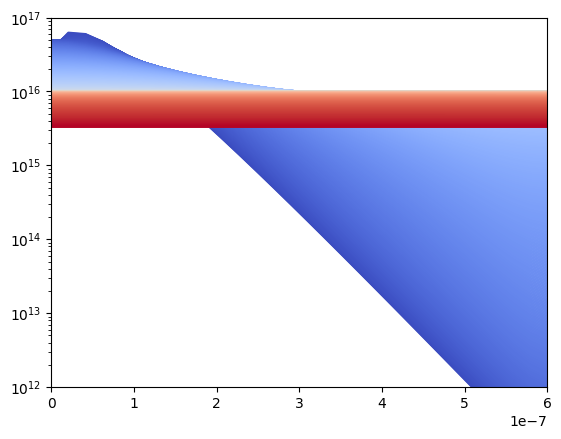

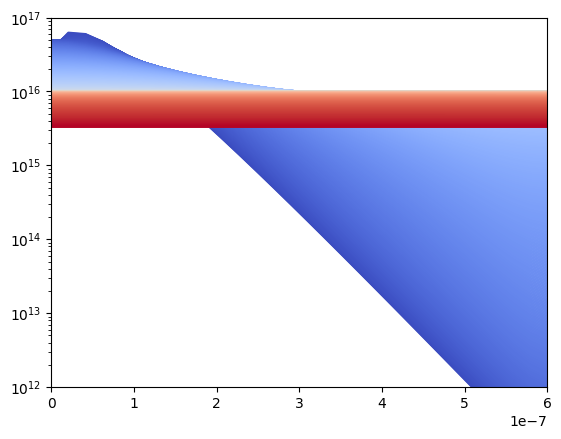

In [20]:
n = n_dens / 1e6
p = p_dens / 1e6
PL = PL
plt.figure()
x = np.linspace(0, Thickness, 30)
# viridis
import matplotlib.cm as cm
import matplotlib.colors as mcolors
cmap = cm.get_cmap('coolwarm',500)

for i in range(len(n_dens)-1):
    # keep evry 10th
    if i % 10 == 0 and i != 0:
        plt.plot(x, n[i], color=cmap(i/len(n_dens)), label=f'{time[i]:.2f}')

plt.yscale('log')
plt.ylim(1e12, 1e17)
plt.xlim(0, Thickness)

plt.figure()
for i in range(len(p_dens)-1):
    # keep evry 10th
    if i % 10 == 0 and i != 0:
        plt.plot(x, p[i], color=cmap(i/len(n_dens)), label=f'{time[i]:.2f}')
plt.yscale('log')
plt.ylim(1e12, 1e17)
plt.xlim(0, Thickness)



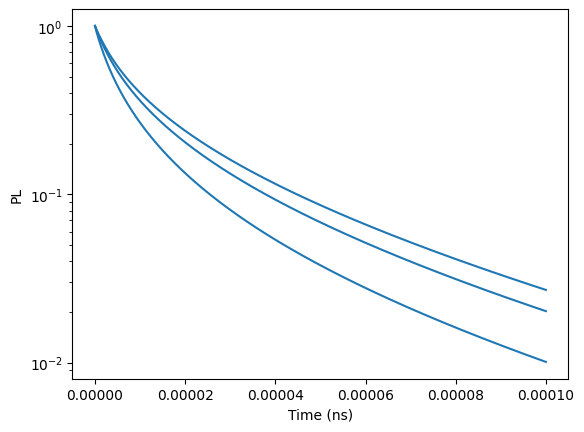

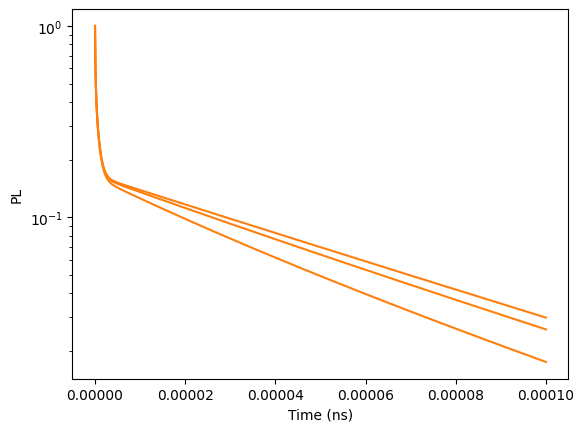

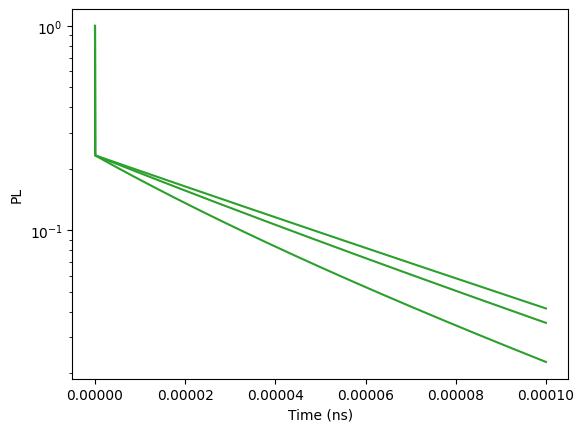

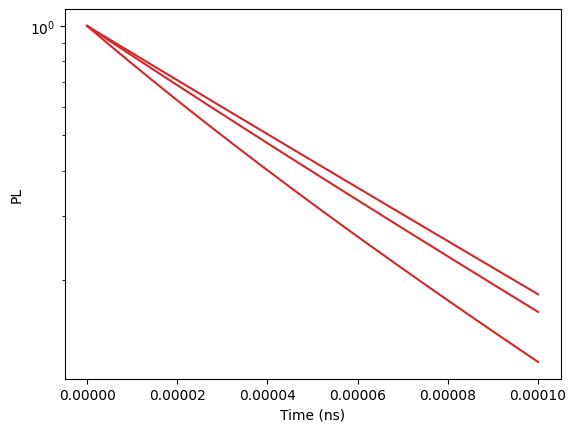

In [6]:
mobs = np.geomspace(1e-4, 1e2, 4) * 1e-4
Fluence = 4.8e11 * 1e4   #cm-2
Fluences = 4.8e11 * 1e4 * np.geomspace(1e-1, 1e0, 3)

for i, mob in enumerate(mobs):
    plt.figure()
    for j, Fluence in enumerate(Fluences):
        PL, n_dens, p_dens = model_in_numpy(time, Fluence, Thickness, alpha, p0, Sfront, Sback, mob, k_rad, k_deep, k_c, k_e)

        plt.plot(time, PL, label=f'{mob:.2f} cm2 V-1 s-1',color='C'+str(i))
    # plt.xscale('log')
    plt.yscale('log')
    # plt.ylim(1e-5, 2e0)
    # plt.ylim(1e0, 1e9)
    plt.xlabel('Time (ns)')
    plt.ylabel('PL')
# plt.legend()

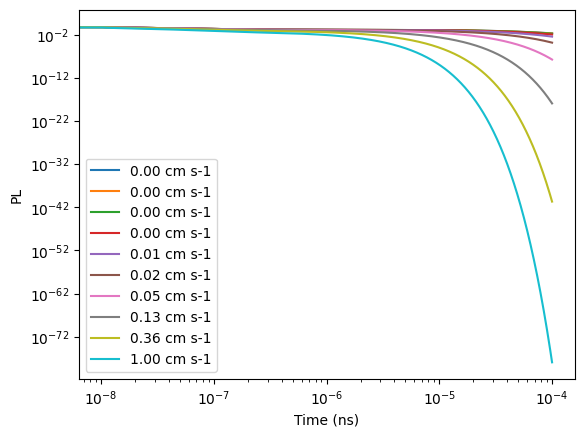

In [ ]:
Sfronts = np.geomspace(1e-2, 1e2, 10) * 1e-2
for i, Sfront in enumerate(Sfronts):
    PL, n_dens, p_dens = model_in_numpy(time, Fluence, Thickness, alpha, p0, Sfront, Sback, Mobility, k_rad, k_deep, k_c, k_e)

    plt.plot(time, PL, label=f'{Sfront:.2f} m s-1')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time (ns)')
plt.ylabel('PL')
plt.legend()
plt.show()

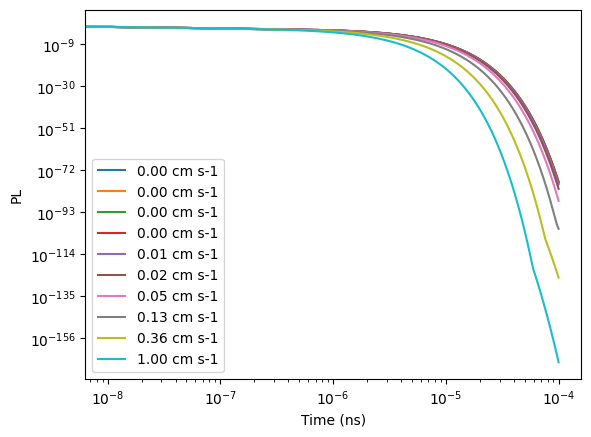

In [ ]:
Sbacks = np.geomspace(1e-2, 1e2, 10) * 1e-2
for i, Sback in enumerate(Sbacks):
    PL, n_dens, p_dens = model_in_numpy(time, Fluence, Thickness, alpha, p0, Sfront, Sback, Mobility, k_rad, k_deep, k_c, k_e)

    plt.plot(time, PL, label=f'{Sback:.2f} m s-1')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time (ns)')
plt.ylabel('PL')
plt.legend()
plt.show()


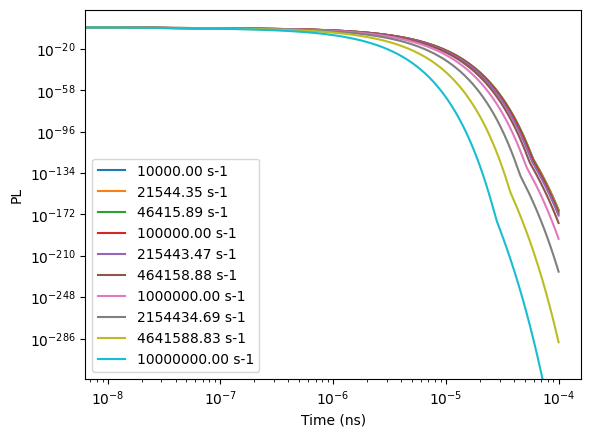

In [9]:
k_deeps = np.geomspace(1e4, 1e7, 10)
for i, k_deep in enumerate(k_deeps):
    PL, n_dens, p_dens = model_in_numpy(time, Fluence, Thickness, alpha, p0, Sfront, Sback, Mobility, k_rad, k_deep, k_c, k_e)

    plt.plot(time, PL, label=f'{k_deep:.2f} s-1')
plt.xscale('log')   
plt.yscale('log')
plt.xlabel('Time (ns)')
plt.ylabel('PL')
plt.legend()
plt.show()


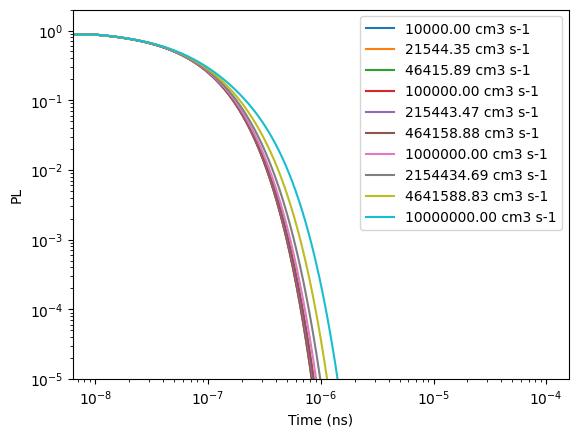

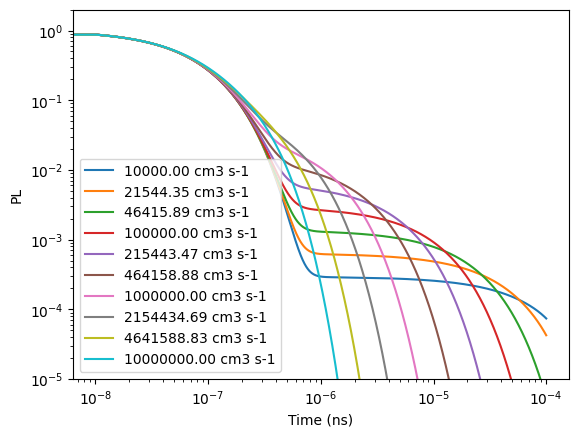

In [ ]:
k_cs = np.geomspace(1e4, 1e7, 10)
k_es = 1e6
plt.figure()
for i, k_c in enumerate(k_cs):
    PL, n_dens, p_dens = model_in_numpy(time, Fluence, Thickness, alpha, p0, Sfront, Sback, Mobility, k_rad, k_deep, k_c, k_e)

    plt.plot(time, PL, label=f'{k_c:.2f} s-1')
plt.ylim(1e-5, 2e0)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time (ns)')
plt.ylabel('PL')
plt.legend()


k_es = np.geomspace(1e4, 1e7, 10)
k_cs = 1e6
plt.figure()
for i, k_e in enumerate(k_es):
    PL, n_dens, p_dens = model_in_numpy(time, Fluence, Thickness, alpha, p0, Sfront, Sback, Mobility, k_rad, k_deep, k_c, k_e)

    plt.plot(time, PL, label=f'{k_e:.2f} s-1')
plt.ylim(1e-5, 2e0)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time (ns)')
plt.ylabel('PL')
plt.legend()
plt.show()


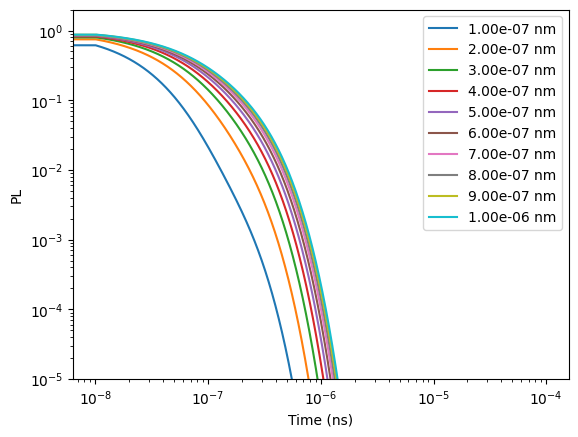

In [15]:
Thicknesss = np.linspace(100, 1000, 10) * 1e-9
Mobility = 1
for i, Thickness in enumerate(Thicknesss):
    PL, n_dens, p_dens = model_in_numpy(time, Fluence, Thickness, alpha, p0, Sfront, Sback, Mobility, k_rad, k_deep, k_c, k_e)

    plt.plot(time, PL, label=f'{Thickness:.2e} m')
plt.ylim(1e-5, 2e0)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time (ns)')
plt.ylabel('PL')
plt.legend()

